# AI Energy Optimization Agent

## AICTE Generative AI & Agentic System Engineering Internship

### Project Title
AI Energy Optimization Agent: An AI-Powered Smart Home Energy Assistant

### Sustainable Development Goal
SDG 13 – Climate Action

### Developed By
<Your Name>

---

## Project Objective

This project uses Google's Gemini AI to analyze household energy consumption, detect excessive electricity usage, provide personalized energy-saving recommendations, and generate sustainability reports supporting SDG 13 – Climate Action.

### Features

- Sample Smart Home Energy Dataset
- Energy Usage Visualization
- AI Energy Consumption Analysis
- High Energy Usage Detection
- Sustainability Recommendations
- AI Generated Report

In [1]:
# ==========================================
# Install Required Libraries
# AI Energy Optimization Agent
# ==========================================

!pip install -q -U google-genai
!pip install -q pandas matplotlib

In [2]:
# ==========================================
# Verify Library Installation
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
from google import genai

print("✅ Pandas Version:", pd.__version__)
print("✅ Google GenAI SDK Installed Successfully")
print("✅ Project Environment Ready")

✅ Pandas Version: 2.2.2
✅ Google GenAI SDK Installed Successfully
✅ Project Environment Ready


In [3]:
# ==========================================
# Gemini API Setup
# ==========================================

from google import genai
from google.colab import userdata

# Read API key from Colab Secrets
api_key = userdata.get("GEMINI_API_KEY")

# Create Gemini client
client = genai.Client(api_key=api_key)

print("✅ Gemini Client Initialized Successfully")

✅ Gemini Client Initialized Successfully


In [4]:
# ==========================================
# Test Gemini API
# ==========================================

response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents="In one sentence, explain why saving electricity helps the environment."
)

print(response.text)

Saving electricity reduces the amount of fossil fuels burned to generate power, thereby lowering greenhouse gas emissions and other pollutants that harm the environment.


In [5]:
# ==========================================
# Step 4: Create Sample Smart Home Energy Dataset
# ==========================================

import pandas as pd

energy_data = {
    "Appliance": [
        "Air Conditioner",
        "Refrigerator",
        "Washing Machine",
        "Television",
        "Ceiling Fan",
        "LED Lights",
        "Microwave",
        "Laptop",
        "Water Heater",
        "Electric Iron"
    ],

    "Daily_Usage_Hours": [
        8,
        24,
        1.5,
        4,
        10,
        6,
        0.5,
        5,
        1,
        0.5
    ],

    "Power_Rating_Watts": [
        1500,
        200,
        500,
        120,
        75,
        15,
        1200,
        65,
        2000,
        1000
    ]
}

df = pd.DataFrame(energy_data)

# Calculate Daily Energy Consumption (kWh)
df["Daily_Energy_kWh"] = (
    df["Daily_Usage_Hours"] *
    df["Power_Rating_Watts"]
) / 1000

# Display dataset
print("Smart Home Energy Dataset")
display(df)

Smart Home Energy Dataset


,Appliance,Daily_Usage_Hours,Power_Rating_Watts,Daily_Energy_kWh
0,Air Conditioner,8.0,1500,12.000
1,Refrigerator,24.0,200,4.800
2,Washing Machine,1.5,500,0.750
3,Television,4.0,120,0.480
4,Ceiling Fan,10.0,75,0.750
5,LED Lights,6.0,15,0.090
6,Microwave,0.5,1200,0.600
7,Laptop,5.0,65,0.325
8,Water Heater,1.0,2000,2.000
9,Electric Iron,0.5,1000,0.500


In [6]:
# ==========================================
# Dataset Summary
# ==========================================

print("Number of Appliances :", len(df))
print("Total Daily Energy Consumption :", round(df["Daily_Energy_kWh"].sum(), 2), "kWh")
print("Average Daily Consumption :", round(df["Daily_Energy_kWh"].mean(), 2), "kWh")

Number of Appliances : 10
Total Daily Energy Consumption : 22.3 kWh
Average Daily Consumption : 2.23 kWh


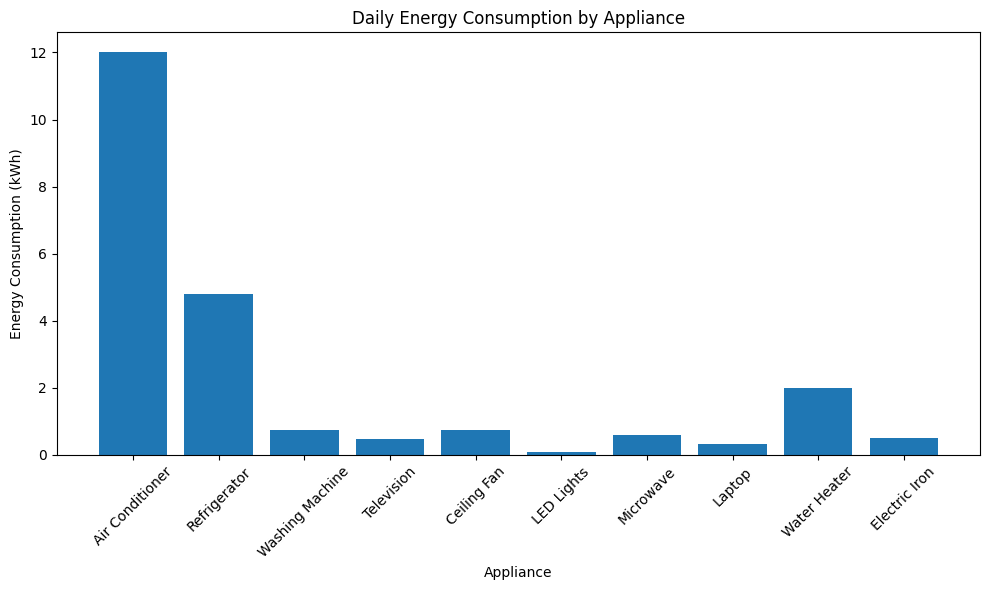

In [7]:
# ==========================================
# Step 5: Energy Usage Visualization
# Bar Chart
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(
    df["Appliance"],
    df["Daily_Energy_kWh"]
)

plt.title("Daily Energy Consumption by Appliance")
plt.xlabel("Appliance")
plt.ylabel("Energy Consumption (kWh)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

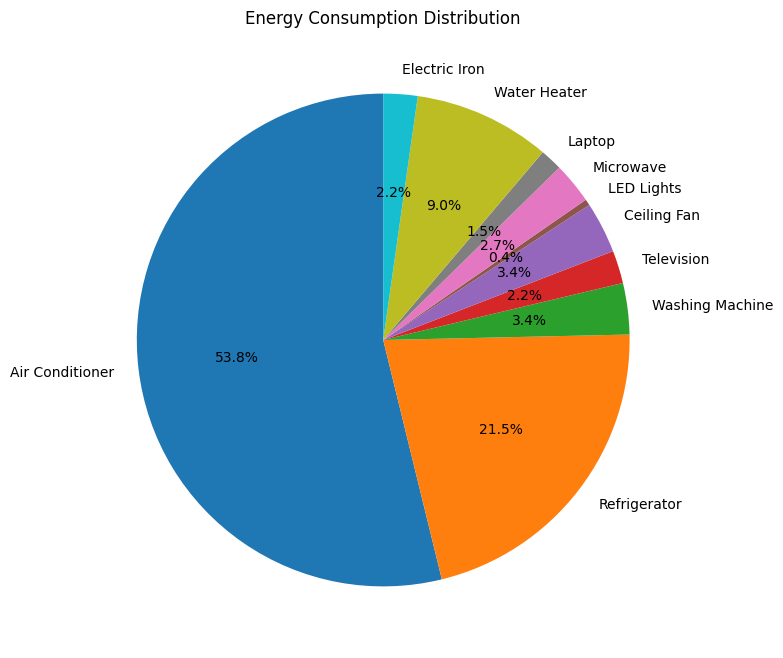

In [8]:
# ==========================================
# Pie Chart
# ==========================================

plt.figure(figsize=(8,8))

plt.pie(
    df["Daily_Energy_kWh"],
    labels=df["Appliance"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Energy Consumption Distribution")

plt.show()

In [9]:
# ==========================================
# Top Energy Consuming Appliances
# ==========================================

top_energy = df.sort_values(
    by="Daily_Energy_kWh",
    ascending=False
)

print("Top Energy Consuming Appliances")

display(top_energy)

Top Energy Consuming Appliances


,Appliance,Daily_Usage_Hours,Power_Rating_Watts,Daily_Energy_kWh
0,Air Conditioner,8.0,1500,12.000
1,Refrigerator,24.0,200,4.800
8,Water Heater,1.0,2000,2.000
2,Washing Machine,1.5,500,0.750
4,Ceiling Fan,10.0,75,0.750
6,Microwave,0.5,1200,0.600
9,Electric Iron,0.5,1000,0.500
3,Television,4.0,120,0.480
7,Laptop,5.0,65,0.325
5,LED Lights,6.0,15,0.090


In [10]:
# ==========================================
# Step 6: Prepare Dataset for Gemini
# ==========================================

# Convert the DataFrame into a readable table
energy_table = df.to_string(index=False)

print(energy_table)

      Appliance  Daily_Usage_Hours  Power_Rating_Watts  Daily_Energy_kWh
Air Conditioner                8.0                1500            12.000
   Refrigerator               24.0                 200             4.800
Washing Machine                1.5                 500             0.750
     Television                4.0                 120             0.480
    Ceiling Fan               10.0                  75             0.750
     LED Lights                6.0                  15             0.090
      Microwave                0.5                1200             0.600
         Laptop                5.0                  65             0.325
   Water Heater                1.0                2000             2.000
  Electric Iron                0.5                1000             0.500


In [11]:
# ==========================================
# AI Energy Analysis using Gemini
# ==========================================

prompt = f"""
You are an AI Energy Optimization Assistant.

Analyze the following household energy consumption dataset.

Dataset:

{energy_table}

Please provide:

1. A summary of the household's energy usage.
2. Which appliances consume the most electricity?
3. Any inefficient energy usage patterns.
4. Three practical recommendations to reduce electricity consumption.
5. Explain how these recommendations support SDG 13 (Climate Action).

Present the response in a professional report format.
"""

response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=prompt
)

print(response.text)

## Household Energy Consumption Report

**Date:** October 26, 2023
**Prepared For:** The Household
**Prepared By:** AI Energy Optimization Assistant

---

### Introduction
This report provides an analysis of the household's energy consumption based on the provided dataset. It aims to identify key areas of electricity usage, highlight potential inefficiencies, and offer actionable recommendations to reduce overall consumption, thereby supporting sustainable practices and climate action.

---

### 1. Summary of the Household's Energy Usage

The household consumes a total of **23.3 kWh of electricity per day**. This is derived from a diverse range of appliances, with a significant portion attributed to high-power devices used for extended periods or specific tasks. The consumption pattern indicates a reliance on several energy-intensive appliances, especially for climate control and water heating, which collectively represent the majority of the daily energy expenditure.

---

### 2. Appl

In [12]:
# ==========================================
# Step 7: High Energy Consumption Detection
# ==========================================

# Threshold (kWh per day)
HIGH_ENERGY_THRESHOLD = 2.0

# Find appliances above the threshold
high_energy = df[df["Daily_Energy_kWh"] > HIGH_ENERGY_THRESHOLD]

print("⚠️ High Energy Consumption Appliances\n")

if high_energy.empty:
    print("No appliances exceeded the threshold.")
else:
    display(high_energy)

⚠️ High Energy Consumption Appliances



,Appliance,Daily_Usage_Hours,Power_Rating_Watts,Daily_Energy_kWh
0,Air Conditioner,8.0,1500,12.0
1,Refrigerator,24.0,200,4.8


In [13]:
# ==========================================
# Smart Energy Alerts
# ==========================================

print("🔔 Smart Energy Alerts\n")

for _, row in high_energy.iterrows():

    print(f"⚠️ {row['Appliance']} is consuming "
          f"{row['Daily_Energy_kWh']:.2f} kWh/day.")

    print("Recommendation: Consider reducing usage or using an energy-efficient alternative.\n")

🔔 Smart Energy Alerts

⚠️ Air Conditioner is consuming 12.00 kWh/day.
Recommendation: Consider reducing usage or using an energy-efficient alternative.

⚠️ Refrigerator is consuming 4.80 kWh/day.
Recommendation: Consider reducing usage or using an energy-efficient alternative.



In [14]:
# ==========================================
# High Energy Summary
# ==========================================

print("========== High Energy Summary ==========\n")

print("Total Appliances:", len(df))
print("High Energy Appliances:", len(high_energy))

print(
    "Total High Energy Consumption:",
    round(high_energy["Daily_Energy_kWh"].sum(), 2),
    "kWh/day"
)

========== High Energy Summary ==========

Total Appliances: 10
High Energy Appliances: 2
Total High Energy Consumption: 16.8 kWh/day


In [15]:
# ==========================================
# Step 8: Prepare High Energy Data
# ==========================================

high_energy_table = high_energy.to_string(index=False)

print(high_energy_table)

      Appliance  Daily_Usage_Hours  Power_Rating_Watts  Daily_Energy_kWh
Air Conditioner                8.0                1500              12.0
   Refrigerator               24.0                 200               4.8


In [16]:
# ==========================================
# SDG 13 Sustainability Recommendations
# ==========================================

prompt = f"""
You are an AI Sustainability Advisor.

The following household appliances have high daily energy consumption:

{high_energy_table}

Please provide:

1. A short explanation of why reducing their energy usage is important.
2. Five personalized energy-saving recommendations.
3. Explain how these recommendations contribute to Sustainable Development Goal (SDG) 13 – Climate Action.
4. Conclude with a short motivational message encouraging sustainable energy habits.

Present the response in a clear, professional format suitable for an internship project report.
"""

response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=prompt
)

sdg_recommendations = response.text

print(sdg_recommendations)

## Household Energy Efficiency Report: Recommendations for Air Conditioner and Refrigerator

**Prepared by:** AI Sustainability Advisor

**Date:** October 26, 2023

---

### Introduction

This report addresses the high daily energy consumption identified for your Air Conditioner (12.0 kWh/day) and Refrigerator (4.8 kWh/day). By implementing strategic changes, significant reductions in energy usage, environmental impact, and utility costs can be achieved.

---

### 1. Importance of Reducing Energy Usage

Reducing energy consumption for high-usage appliances like air conditioners and refrigerators is critically important for several reasons:

*   **Environmental Impact:** A significant portion of global electricity is generated from fossil fuels (coal, natural gas, oil). Burning these fuels releases greenhouse gases (GHGs) like carbon dioxide (CO2) into the atmosphere, which are the primary drivers of climate change, global warming, and extreme weather events. Lowering electricity demand

In [17]:
# ==========================================
# Step 9: AI Energy Optimization Report
# ==========================================

report_prompt = f"""
You are an AI Energy Consultant.

Create a professional Energy Optimization Report based on the following information.

Household Energy Dataset:

{energy_table}

High Energy Appliances:

{high_energy_table}

Previous AI Analysis:

{response.text}

The report should contain:

1. Report Title
2. Executive Summary
3. Energy Consumption Analysis
4. High Energy Consumption Findings
5. Sustainability Recommendations
6. SDG 13 – Climate Action Impact
7. Final Conclusion

Use professional language suitable for an AICTE internship project.
"""

report_response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=report_prompt
)

final_report = report_response.text

print(final_report)

## Household Energy Optimization Report: Strategies for Enhanced Sustainability and Efficiency

**Prepared for:** The Valued Household
**Prepared by:** AI Energy Consultant
**Date:** October 26, 2023
**Project:** AICTE Internship Project - Energy Management

---

### 1. Report Title

**Household Energy Optimization Report: Strategic Recommendations for Reducing Energy Footprint and Utility Costs**

---

### 2. Executive Summary

This report provides a comprehensive analysis of the household's daily energy consumption, identifying key areas for optimization. Based on the provided dataset, the Air Conditioner and Refrigerator have been identified as the predominant energy consumers, accounting for over 75% of the total daily electricity usage. Building upon a previous AI analysis, this document outlines five specific, actionable recommendations aimed at significantly reducing the energy consumption of these high-impact appliances. Implementation of these strategies will not only lead to 

In [21]:
# ==========================================
# Save AI Report
# ==========================================

with open("AI_Energy_Optimization_Report.txt", "w", encoding="utf-8") as file:
    file.write(final_report)

print("✅ Report saved successfully as AI_Energy_Optimization_Report.txt")

✅ Report saved successfully as AI_Energy_Optimization_Report.txt


In [22]:
import os

print(os.listdir())

['.config', 'AI_Energy_Optimization_Report.txt', 'sample_data']


In [23]:
from google.colab import files

files.download("AI_Energy_Optimization_Report.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>



```
# Conclusion

The AI Energy Optimization Agent demonstrates how Generative AI can support sustainable energy management through intelligent analysis and personalized recommendations.

The system:

- Monitors household energy usage.
- Identifies high energy consumption.
- Generates AI-powered recommendations.
- Supports SDG 13 – Climate Action.
- Produces professional energy optimization reports.

This project showcases the practical application of Google's Gemini AI in building an intelligent energy optimization assistant for smart homes.
```

